In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import bz2
from collections import Counter
from nltk.util import ngrams
from nltk.corpus import stopwords
import nltk


nltk.download('stopwords')

df = pd.read_csv(r"C:\Users\RAJEET\OneDrive\Desktop\A,A,P   tops\NLP\Assessment\test.ft.txt.bz2",
    sep="\t",
    header=None,
    names=["text"],
    engine="python",
    encoding="latin-1"
)

# Remove labels
df["review"] = df["text"].str.replace("__label__1 ", "", regex=False)
df["review"] = df["review"].str.replace("__label__2 ", "", regex=False)
# Create category labels
df["category"] = df["text"].apply(
    lambda x: "Positive" if "__label__2" in str(x) else "Negative")
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\RAJEET\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df

,text,review,category
0,__label__2 Great CD: My lovely Pat has one of ...,Great CD: My lovely Pat has one of the GREAT v...,Positive
1,__label__2 One of the best game music soundtra...,One of the best game music soundtracks - for a...,Positive
2,__label__1 Batteries died within a year ...: I...,Batteries died within a year ...: I bought thi...,Negative
3,"__label__2 works fine, but Maha Energy is bett...","works fine, but Maha Energy is better: Check o...",Positive
4,__label__2 Great for the non-audiophile: Revie...,Great for the non-audiophile: Reviewed quite a...,Positive
...,...,...,...
399995,__label__1 Unbelievable- In a Bad Way: We boug...,Unbelievable- In a Bad Way: We bought this Tho...,Negative
399996,"__label__1 Almost Great, Until it Broke...: My...","Almost Great, Until it Broke...: My son reciev...",Negative
399997,__label__1 Disappointed !!!: I bought this toy...,Disappointed !!!: I bought this toy for my son...,Negative
399998,__label__2 Classic Jessica Mitford: This is a ...,Classic Jessica Mitford: This is a compilation...,Positive


In [3]:

def clean_text(text):


    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return words
# Apply cleaning
df["tokens"] = df["review"].apply(clean_text)


In [4]:
df

,text,review,category,tokens
0,__label__2 Great CD: My lovely Pat has one of ...,Great CD: My lovely Pat has one of the GREAT v...,Positive,"[great, cd, lovely, pat, one, great, voices, g..."
1,__label__2 One of the best game music soundtra...,One of the best game music soundtracks - for a...,Positive,"[one, best, game, music, soundtracks, game, re..."
2,__label__1 Batteries died within a year ...: I...,Batteries died within a year ...: I bought thi...,Negative,"[batteries, died, within, year, bought, charge..."
3,"__label__2 works fine, but Maha Energy is bett...","works fine, but Maha Energy is better: Check o...",Positive,"[works, fine, maha, energy, better, check, mah..."
4,__label__2 Great for the non-audiophile: Revie...,Great for the non-audiophile: Reviewed quite a...,Positive,"[great, non, audiophile, reviewed, quite, bit,..."
...,...,...,...,...
399995,__label__1 Unbelievable- In a Bad Way: We boug...,Unbelievable- In a Bad Way: We bought this Tho...,Negative,"[unbelievable, bad, way, bought, thomas, son, ..."
399996,"__label__1 Almost Great, Until it Broke...: My...","Almost Great, Until it Broke...: My son reciev...",Negative,"[almost, great, broke, son, recieved, birthday..."
399997,__label__1 Disappointed !!!: I bought this toy...,Disappointed !!!: I bought this toy for my son...,Negative,"[disappointed, bought, toy, son, loves, thomas..."
399998,__label__2 Classic Jessica Mitford: This is a ...,Classic Jessica Mitford: This is a compilation...,Positive,"[classic, jessica, mitford, compilation, wide,..."


In [5]:
from nltk import ngrams
from collections import Counter

text = " ".join(df['review'].astype(str)).lower().split()

bigrams = Counter(ngrams(text, 2))
trigrams = Counter(ngrams(text, 3))

print("Top 10 Bigrams:")
print(bigrams.most_common(10))

print("\nTop 10 Trigrams:")
print(trigrams.most_common(10))

Top 10 Bigrams:
[(('of', 'the'), 159269), (('in', 'the'), 93551), (('is', 'a'), 78456), (('this', 'book'), 72488), (('this', 'is'), 70741), (('it', 'is'), 69799), (('i', 'have'), 61925), (('and', 'the'), 60287), (('on', 'the'), 56903), (('to', 'the'), 54857)]

Top 10 Trigrams:
[(('this', 'is', 'a'), 21649), (('one', 'of', 'the'), 19783), (('this', 'book', 'is'), 16353), (('a', 'lot', 'of'), 13069), (('i', 'bought', 'this'), 12048), (('this', 'is', 'the'), 11465), (('it', 'is', 'a'), 10493), (('if', 'you', 'are'), 10491), (('some', 'of', 'the'), 9063), (('is', 'a', 'great'), 8785)]


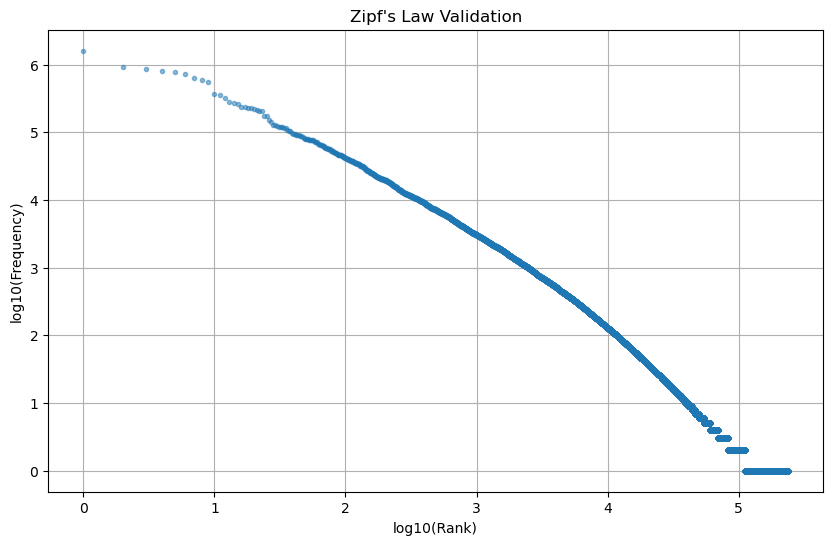

In [7]:
# Zipf's Law Validation: Log-Rank vs Log-Frequency Plot

word_freq = Counter()

with bz2.open("test.ft.txt.bz2", 'rt', encoding='utf-8', errors='ignore') as file:
    for line in file:
        # Extract words only
        words = re.findall(r'\b[a-zA-Z]+\b', line.lower())
        word_freq.update(words)

frequencies = sorted(word_freq.values(), reverse=True)

ranks = np.arange(1, len(frequencies) + 1)

log_ranks = np.log10(ranks)
log_freqs = np.log10(frequencies)

plt.figure(figsize=(10, 6))
plt.plot(log_ranks, log_freqs, marker='.', linestyle='none', alpha=0.5)

plt.title("Zipf's Law Validation")
plt.xlabel("log10(Rank)")
plt.ylabel("log10(Frequency)")
plt.grid(True)

plt.show()
